# Banner creation

## Environment set up

In [ ]:
import os, requests, json, re
import zipfile
import io
import time
from urllib.parse import urlparse
from bs4 import BeautifulSoup

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown

from PIL import Image as PIL_Image
from PIL import ImageDraw, ImageFont
from google import genai
from google.genai.types import (
    EditImageConfig,
    GenerateImagesConfig,
    Image,
    MaskReferenceConfig,
    MaskReferenceImage,
    RawReferenceImage,
    GenerateContentConfig,
    Part,
    SafetySetting,
    ThinkingConfig,
)

from vertexai.preview.vision_models import (
    ImageSegmentationModel,
    ImageSegmentationResponse,
)
from vertexai.preview.vision_models import Image as Vertex_Image

## Configuration - colours and fonts

In [1]:
# Colors
COLOR_WHITE = (255, 255, 255)
COLOR_BLACK = (0, 0, 0)
COLOR_DARK_GRAY = (50, 50, 50)
COLOR_BRAND_PURPLE = (45, 25, 66)
COLOR_LIGHT_PURPLE_BG = (244, 242, 247)
COLOR_WAS_PRICE_BG = (239, 68, 68) # A reddish color for the 'Was' price

# # Dimensions
# BANNER_WIDTH = 1200
# BANNER_HEIGHT = 400
# SIDE_PANEL_WIDTH = 450
# PRODUCT_AREA_X_START = 470
# PRODUCT_IMAGE_HEIGHT = 200

# # Padding and Spacing
# PADDING = 20
# PRODUCT_SPACING = 30 # Space between products

# Dimensions
BANNER_WIDTH = 1800
BANNER_HEIGHT = 350
SIDE_PANEL_WIDTH = 450
PRODUCT_AREA_X_START = 600
PRODUCT_IMAGE_HEIGHT = 250

# Padding and Spacing
PADDING = 20
PRODUCT_SPACING = 5 # Space between products

Downloaded inter font from https://fonts.google.com/

In [ ]:
!wget -O Inter.zip https://github.com/rsms/inter/releases/download/v4.1/Inter-4.1.zip
!mkdir  fonts
!unzip -o Inter.zip -d fonts/Inter
!ls fonts/Inter/*ttf

21.79s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


--2025-11-13 17:23:35--  https://github.com/rsms/inter/releases/download/v4.1/Inter-4.1.zip
Resolving github.com (github.com)... 20.26.156.215
Connecting to github.com (github.com)|20.26.156.215|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/101033179/c9d3bddb-65c6-4c26-a54e-95666e8e448b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-13T18%3A07%3A12Z&rscd=attachment%3B+filename%3DInter-4.1.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-13T17%3A06%3A36Z&ske=2025-11-13T18%3A07%3A12Z&sks=b&skv=2018-11-09&sig=uxm51BtSTPKC7AiJ6SIOIsCUvqNvsyHXUgAmRAdnbZk%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2MzA1NjQxNSwibmJmIjoxNzYzMDU0NjE1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2l

In [ ]:
# Fonts
vari_font = "fonts/Inter/Inter-VariableFont_opsz,wght.ttf"
vari_font = "fonts/Inter/InterVariable.ttf"
try:
    FONT_BOLD = ImageFont.truetype(vari_font, 40)
    FONT_REGULAR = ImageFont.truetype(vari_font, 18)
    FONT_CTA = ImageFont.truetype(vari_font, 16)
    FONT_PRICE = ImageFont.truetype(vari_font, 22)
    FONT_PRICE_SMALL = ImageFont.truetype(vari_font, 14)
    print("Using custom font Inter")
except IOError:
    print("Fonts not found. Using PIL's default font.")
    FONT_BOLD = ImageFont.load_default()
    FONT_REGULAR = ImageFont.load_default()
    FONT_CTA = ImageFont.load_default()
    FONT_PRICE = ImageFont.load_default()
    FONT_PRICE_SMALL = ImageFont.load_default()

Using custom font Inter


In [ ]:
PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))
LOCATION = str(os.environ.get("GOOGLE_CLOUD_REGION"))
print(f"Project ID: {PROJECT_ID}")
print(f"Location: {LOCATION}")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)
edit_model = "imagen-3.0-capability-001"
print(f"Edit model: {edit_model}")

IMAGE_SEGMENTATION_MODEL = "image-segmentation-001"
segmentation_model = ImageSegmentationModel.from_pretrained(IMAGE_SEGMENTATION_MODEL)

print(f"Segmentation model: {IMAGE_SEGMENTATION_MODEL}")
GEMINI_MODEL_ID = "gemini-2.5-flash"
print(f"Gemini model: {GEMINI_MODEL_ID}")

Project ID: uk-bh-experiments-argolis
Location: us-central1
Edit model: imagen-3.0-capability-001
Segmentation model: image-segmentation-001
Gemini model: gemini-2.5-flash


## Helper functions

In [ ]:
def display_row(images: list, figsize: tuple[int, int] = (12, 12), bg: str = "white"):
    fig, axes = plt.subplots(1, len(images), figsize=figsize, squeeze=False, facecolor=bg)

    for i, ax in enumerate(axes.ravel()):
        ax.imshow(images[i].convert("RGBA"))
        ax.axis("off")

    plt.show()

In [ ]:
def scrape_ocado_product(url):
    """
    Scrapes the title, price, and main image from a single Ocado product page.

    Args:
        url (str): The URL of the Ocado product page.

    Returns:
        dict: A dictionary containing the scraped data (URL, Title, Price, Image URL),
              or None if the request fails.
    """
    # Headers to mimic a browser visit, which helps prevent being blocked
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    try:
        # Fetch the content of the page with a timeout
        response = requests.get(url, headers=headers, timeout=10)
        # Raise an exception for bad status codes (like 404 or 500)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching {url}: {e}")
        return None

    soup = BeautifulSoup(response.content, 'html.parser')

    # --- Extract the information using the refined selectors ---

    # Find the h1 inside the header with class 'bop-title'
    title_tag = soup.select_one('header.bop-title h1')
    # Use separator=' ' to ensure a space between the product name and its weight/quantity
    title = title_tag.get_text(separator=' ', strip=True) if title_tag else "Not Found"

    # Extract the price from the H2 tag with the specific class
    price_tag = soup.find('h2', class_='bop-price__current')
    price = price_tag.text.strip() if price_tag else "Not Found"

    # Extract the main image URL
    image_tag = soup.find('img', class_='bop-gallery__image')
    # The src attribute is a relative path, so we prepend the base URL
    image_url = f"https://www.ocado.com{image_tag['src']}" if image_tag and image_tag.has_attr('src') else "Not Found"

    # Return the data as a dictionary
    return {
        "url": url,
        "title": title,
        "price": price,
        "image_url": image_url
    }

In [ ]:
def scrape_ocado_product_v2(url):
    """
    Scrapes the title, price, and main image from a single Ocado product page
    by parsing embedded structured data (JSON-LD).

    Args:
        url (str): The URL of the Ocado product page.

    Returns:
        dict: A dictionary containing the scraped data (URL, Title, Price, Image URL),
              or None if the request fails or data cannot be found.
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching {url}: {e}")
        return None

    soup = BeautifulSoup(response.content, 'html.parser')

    # ---  Find the structured data script ---
    script_tag = soup.find('script', {'type': 'application/ld+json'})

    if not script_tag:
        print(f"Could not find structured data on page: {url}")
        return None

    try:
        # Load the content of the script tag as a JSON object
        product_data = json.loads(script_tag.string)

        # Extract the information from the JSON data
        # The 'name' and 'size' are separate; we combine them for a full title.
        title = f"{product_data.get('name', '')} {product_data.get('size', '')}".strip()

        # The price is nested inside the 'offers' dictionary
        price = product_data.get('offers', {}).get('price', 'Not Found')
        # Add currency symbol for clarity
        if price != "Not Found":
             price = f"£{price}"

        # The 'image' key often contains a list of URLs; we'll take the first one.
        image_urls = product_data.get('image', [])
        image_url = image_urls[0] if image_urls else "Not Found"

        # Return the data as a dictionary
        return {
            "url": url,
            "title": title,
            "price": price,
            "image_url": image_url
        }

    except (json.JSONDecodeError, KeyError, IndexError) as e:
        print(f"Error parsing JSON data from {url}: {e}")
        return None

In [ ]:
def display_products_html(df):
    """
    Takes a DataFrame and displays it as a rich HTML report, with full control
    over the button colors.
    """
    # --- Easy Customization Area ---
    # Change these hex codes or use color names (e.g., 'black', 'lightgray')
    button_bg_color = '#d8b4fe'  # This is the hex code for Tailwind's purple-300
    button_text_color = '#3b0764' # A dark purple for good contrast

    html_output = f"""
    <script src="https://cdn.tailwindcss.com"></script>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
    <style>
        .card-container-jupyter {{
            display: flex; flex-wrap: nowrap; overflow-x: auto;
            padding-bottom: 1rem; gap: 1.5rem; font-family: 'Inter', sans-serif;
        }}
        /* NEW: Added a rule to handle the button hover effect dynamically */
        .custom-btn:hover {{
            filter: brightness(95%); /* Makes the button slightly darker on hover */
        }}
    </style>
    <div class="p-4">
        <header class="text-center mb-8">
            <h1 class="text-3xl font-bold text-gray-800">Products</h1>
        </header>
        <div class="card-container-jupyter">
    """

    for index, row in df.iterrows():
        html_output += f"""
            <div style="width: 200px; flex-shrink: 0;" class="bg-white rounded-lg shadow-md overflow-hidden transform hover:scale-105 transition-transform duration-300">
                <div class="w-full h-56">
                    <img src="{row['image_url']}" alt="Image of {row['title']}" class="w-full h-full object-cover">
                </div>
                <div class="p-4 flex flex-col h-48">
                    <h2 style="font-size: 14px;" class="font-semibold text-gray-800 flex-grow">{row['title']}</h2>
                    <p class="text-2xl font-bold text-purple-700 my-3">{row['price']}</p>
                    <a href="{row['url']}" target="_blank"
                       class="custom-btn block w-full text-center font-bold py-2 px-3 rounded-lg transition-all duration-300 text-sm"
                       style="background-color: {button_bg_color}; color: {button_text_color}; text-decoration: none;">
                        View Product
                    </a>
                </div>
            </div>
        """

    html_output += "</div></div>"
    display(HTML(html_output))


In [ ]:
def remove_background(image_path):
    BASE_IMAGE = Vertex_Image.load_from_file(location=image_path)
    BASE_IMAGE_PIL = BASE_IMAGE._pil_image
    response = segmentation_model.segment_image(base_image=BASE_IMAGE, mode="foreground", binary_color_threshold=-1)
    MASK_PIL = response.masks[0]._pil_image
    # Creates an empty transparent background.
    transparent_background = PIL_Image.new("RGBA", BASE_IMAGE_PIL.size, (128, 128, 128, 255))
    # Uses the mask to cut and paste the foreground object in the original image
    # onto the transparent background.
    transparent_background.paste(BASE_IMAGE_PIL, mask=MASK_PIL)
    transparent_background.putalpha(MASK_PIL)

    directory = os.path.dirname(image_path)
    filename_with_ext = os.path.basename(image_path)
    filename, extension = os.path.splitext(filename_with_ext)

    new_filename = f"{filename}_seg.png"
    save_path = os.path.join(directory, new_filename)
    transparent_background.save(save_path)
    print(f"Processed image saved to: {save_path}")
    return save_path

In [ ]:
schema = {
  "title": "Marketing Content",
  "description": "Schema for marketing headline and sub-headline content.",
  "type": "object",
  "properties": {
    "headline": {
      "type": "string",
      "description": "The main selling point or primary title."
    },
    "sub_headline": {
      "type": "string",
      "description": "A catchy supporting phrase or secondary title."
    }
  },
  "required": [
    "headline",
    "sub_headline"
  ]
}

In [ ]:
def get_copy(prompt):
    response = client.models.generate_content(
        model=GEMINI_MODEL_ID,
        contents=prompt,
        config=GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=schema,
            thinking_config=ThinkingConfig(
                thinking_budget=0,
            ),

        ),
    )

    return response.text

In [ ]:
def draw_price_tag(draw, position, now_price, offer):
    """Draws the complex price tag above a product."""
    x, y = position
    tag_width = 120
    tag_height = 60

    # Bounding box for the entire price tag
    box = (x, y, x + tag_width, y + tag_height)
    draw.rounded_rectangle(box, radius=8, fill=COLOR_WHITE, outline=(220, 220, 220), width=1)

    # "Now" Price
    now_text = "Now"
    draw.text((x + 10, y + 8), now_text, font=FONT_PRICE_SMALL, fill=COLOR_DARK_GRAY)
    draw.text((x + 45, y + 5), f"{now_price}", font=FONT_PRICE, fill=COLOR_BLACK)

    # "Was" Price background
    was_box_y = y + 35
    was_box = (x + 10, was_box_y, x + tag_width - 10, was_box_y + 20)
    draw.rectangle(was_box, fill=COLOR_WAS_PRICE_BG)

    # "Was" Price text
    was_text = f"{offer}"
    # Get text size to center it and draw the strikethrough
    try:
        was_text_length = draw.textlength(was_text, font=FONT_PRICE_SMALL)
    except AttributeError: # Fallback for older Pillow versions
        was_text_length = FONT_PRICE_SMALL.getsize(was_text)[0]

    was_text_pos_x = x + 10 + ( (tag_width - 20) - was_text_length) / 2
    was_text_pos_y = was_box_y + 3
    draw.text((was_text_pos_x, was_text_pos_y), was_text, font=FONT_PRICE_SMALL, fill=COLOR_WHITE)

    # # Strikethrough line
    # line_y = was_text_pos_y + 7
    # draw.line((was_text_pos_x - 2, line_y, was_text_pos_x + was_text_length + 2, line_y), fill=COLOR_WHITE, width=1)

def create_banner(headline, subheadline, cta_text, terms_text, products, output_filename="banner.png"):
    """
    Generates a promotional banner with dynamic product placement.

    Args:
        headline (str): The main headline text.
        subheadline (str): The supporting sub-headline text.
        cta_text (str): Text for the Call-to-Action button.
        terms_text (str): Text for terms and conditions.
        products (list of dict): A list of product information. Each dict should have
                                 'image_path', 'now_price', and 'offer'.
        output_filename (str): The name of the output image file.
    """
    # 1. Create the base image and background layers
    banner = PIL_Image.new('RGB', (BANNER_WIDTH, BANNER_HEIGHT), COLOR_WHITE)
    draw = ImageDraw.Draw(banner)

    # Draw the light purple background band for the text area
    draw.rectangle([0, 0, BANNER_WIDTH, BANNER_HEIGHT], fill=COLOR_LIGHT_PURPLE_BG)

    # 2. Draw the text content on the left panel
    current_y = 80

    # Headline
    draw.text((PADDING, current_y), headline, font=FONT_BOLD, fill=COLOR_BLACK)
    current_y += 70

    # Sub-headline
    draw.text((PADDING, current_y), subheadline, font=FONT_REGULAR, fill=COLOR_DARK_GRAY)
    current_y += 40

    # CTA Button
    cta_padding_x = 20
    cta_padding_y = 10
    try:
        cta_text_width = draw.textlength(cta_text, font=FONT_CTA)
        cta_text_height = 20 # Approximate height based on font size
    except AttributeError:
        cta_text_width, cta_text_height = FONT_CTA.getsize(cta_text)

    cta_box = [
        PADDING,
        current_y,
        PADDING + cta_text_width + cta_padding_x * 2,
        current_y + cta_text_height + cta_padding_y * 2
    ]
    draw.rounded_rectangle(cta_box, radius=5, fill=COLOR_BRAND_PURPLE)

    # CTA Text
    cta_text_x = cta_box[0] + cta_padding_x
    cta_text_y = cta_box[1] + cta_padding_y
    draw.text((cta_text_x, cta_text_y), cta_text, font=FONT_CTA, fill=COLOR_WHITE)

    current_y = cta_box[3] + 20

    # Terms & Conditions
    draw.text((PADDING, current_y), terms_text, font=FONT_REGULAR, fill=COLOR_DARK_GRAY)

    # 3. Process and place products
    num_products = len(products)
    if num_products == 0:
        print("Warning: No products provided.")
    else:
        # Calculate the starting X position to center the block of products
        total_product_width = sum(
            int(PRODUCT_IMAGE_HEIGHT * PIL_Image.open(p['image_path']).width / PIL_Image.open(p['image_path']).height)
            for p in products
        )
        total_spacing_width = PRODUCT_SPACING * (num_products - 1)
        total_block_width = total_product_width + total_spacing_width
        # print(total_block_width)

        available_width = BANNER_WIDTH - PRODUCT_AREA_X_START
        # print(available_width)
        current_x = PRODUCT_AREA_X_START + (available_width - total_block_width) / 2

        for product in products:
            # Open and resize product image while maintaining aspect ratio
            with PIL_Image.open(product['image_path']) as prod_img:
                prod_img.thumbnail((BANNER_WIDTH, PRODUCT_IMAGE_HEIGHT)) # Preserves aspect ratio

                # Paste product image onto the banner
                image_y = BANNER_HEIGHT - prod_img.height - PADDING
                banner.paste(prod_img, (int(current_x), image_y), prod_img if prod_img.mode == 'RGBA' else None)

                # Draw the price tag above the product image
                price_tag_x = int(current_x + (prod_img.width / 2) - 60) # Center the tag
                price_tag_y = image_y - 70 # 60px height + 10px spacing
                draw_price_tag(draw, (price_tag_x, price_tag_y), product['now_price'], product['offer'])

                # Update current_x for the next product
                current_x += prod_img.width + PRODUCT_SPACING
                # print(current_x, prod_img.width, PRODUCT_SPACING)

    # 4. Save the final banner
    banner.save(output_filename)
    print(f"Banner saved as {output_filename}")

## Get info from website

In [ ]:
product_list = [
    "https://www.ocado.com/products/canvin-gunner-smash-burgers-662652011",
    "https://www.ocado.com/products/big-k-barbecue-charcoal-briquettes-fsc-551541011",
    "https://www.ocado.com/products/pimm-s-no-1-cup-26026011",
    "https://www.ocado.com/products/m-s-calabrian-chilli-marinated-italian-mozzarella-660278011",
]

output_product_csv_filename = "products_bbq_v2.csv"

In [ ]:
all_products_data = []

output_image_dir = 'product_images_v2'
os.makedirs(output_image_dir, exist_ok=True)
print(f"Images will be saved to the '{output_image_dir}' directory.")

print("\nStarting scraper...")

for url in product_list:
    print(f"Scraping: {url}")
    # product_data = scrape_ocado_product(url)
    product_data = scrape_ocado_product_v2(url)

    if product_data:
        all_products_data.append(product_data)
        image_url = product_data.get('image_url')
        title = product_data.get('title')
        if image_url:
            try:
                image_response = requests.get(image_url, stream=True)
                if image_response.status_code == 200:
                    parsed_url = urlparse(image_url)
                    # Convert to lowercase, replace spaces with hyphens
                    slug = title.lower().replace(" ", "-")
                    # Remove any character that is not a letter, number, or hyphen
                    slug = re.sub(r'[^\w-]', '', slug)
                    image_filename = slug + os.path.basename(parsed_url.path)
                    file_path = os.path.join(output_image_dir, image_filename)

                    with open(file_path, 'wb') as f:
                        for chunk in image_response.iter_content(1024):
                            f.write(chunk)

                    product_data['local_image_path'] = file_path
                    print(f"  -> 🖼️ Image saved: {image_filename}")
                else:
                    print(f"  -> ⚠️  Warning: Could not download image. Status code:{image_response.status_code}")
            except requests.exceptions.RequestException as e:
                print(f"  -> ❌ Error downloading image: {e}")
        else:
            print("  -> ⚠️  Warning: No image URL found for this product.")
    time.sleep(1)

print("\nScraping complete.")

df = pd.DataFrame(all_products_data)
display(df)

df.to_csv(output_product_csv_filename, index=False, encoding='utf-8')
print(f"\nData saved to {output_product_csv_filename}")

Images will be saved to the 'product_images_v2' directory.

Starting scraper...
Scraping: https://www.ocado.com/products/canvin-gunner-smash-burgers-662652011
  -> 🖼️ Image saved: canvin--gunner-smash-burgers-400g500x500.jpg
Scraping: https://www.ocado.com/products/big-k-barbecue-charcoal-briquettes-fsc-551541011
  -> 🖼️ Image saved: big-k-barbecue-charcoal-briquettes-fsc-3kg500x500.jpg
Scraping: https://www.ocado.com/products/pimm-s-no-1-cup-26026011
  -> 🖼️ Image saved: pimms-no1-cup-1l500x500.jpg
Scraping: https://www.ocado.com/products/m-s-calabrian-chilli-marinated-italian-mozzarella-660278011
  -> 🖼️ Image saved: ms-calabrian-chilli-marinated-italian-mozzarella-160g500x500.jpg

Scraping complete.


,url,title,price,image_url,local_image_path
0,https://www.ocado.com/products/canvin-gunner-s...,Canvin & Gunner Smash Burgers 400g,£6.00,https://www.ocado.com/images-v3/eafa5127-d256-...,product_images_v2/canvin--gunner-smash-burgers...
1,https://www.ocado.com/products/big-k-barbecue-...,Big K Barbecue Charcoal Briquettes FSC 3kg,£6.00,https://www.ocado.com/images-v3/eafa5127-d256-...,product_images_v2/big-k-barbecue-charcoal-briq...
2,https://www.ocado.com/products/pimm-s-no-1-cup...,Pimm's No.1 Cup 1L,£25.00,https://www.ocado.com/images-v3/eafa5127-d256-...,product_images_v2/pimms-no1-cup-1l500x500.jpg
3,https://www.ocado.com/products/m-s-calabrian-c...,M&S Calabrian Chilli Marinated Italian Mozzare...,£3.90,https://www.ocado.com/images-v3/eafa5127-d256-...,product_images_v2/ms-calabrian-chilli-marinate...



Data saved to products_bbq_v2.csv


## Read in existing product data

In [ ]:
df = pd.read_csv('products_bbq_v2.csv')
display_products_html(df)

In [ ]:
df

,url,title,price,image_url,local_image_path
0,https://www.ocado.com/products/canvin-gunner-s...,Canvin & Gunner Smash Burgers 400g,£6.00,https://www.ocado.com/images-v3/eafa5127-d256-...,product_images_v2/canvin--gunner-smash-burgers...
1,https://www.ocado.com/products/big-k-barbecue-...,Big K Barbecue Charcoal Briquettes FSC 3kg,£6.00,https://www.ocado.com/images-v3/eafa5127-d256-...,product_images_v2/big-k-barbecue-charcoal-briq...
2,https://www.ocado.com/products/pimm-s-no-1-cup...,Pimm's No.1 Cup 1L,£25.00,https://www.ocado.com/images-v3/eafa5127-d256-...,product_images_v2/pimms-no1-cup-1l500x500.jpg
3,https://www.ocado.com/products/m-s-calabrian-c...,M&S Calabrian Chilli Marinated Italian Mozzare...,£3.90,https://www.ocado.com/images-v3/eafa5127-d256-...,product_images_v2/ms-calabrian-chilli-marinate...


## Process images

/usr/local/lib/python3.11/dist-packages/vertexai/vision_models/_vision_models.py:153: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Processed image saved to: product_images_v2/canvin--gunner-smash-burgers-400g500x500_seg.png


/usr/local/lib/python3.11/dist-packages/vertexai/vision_models/_vision_models.py:153: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Processed image saved to: product_images_v2/big-k-barbecue-charcoal-briquettes-fsc-3kg500x500_seg.png


/usr/local/lib/python3.11/dist-packages/vertexai/vision_models/_vision_models.py:153: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Processed image saved to: product_images_v2/pimms-no1-cup-1l500x500_seg.png


/usr/local/lib/python3.11/dist-packages/vertexai/vision_models/_vision_models.py:153: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Processed image saved to: product_images_v2/ms-calabrian-chilli-marinated-italian-mozzarella-160g500x500_seg.png

Original images


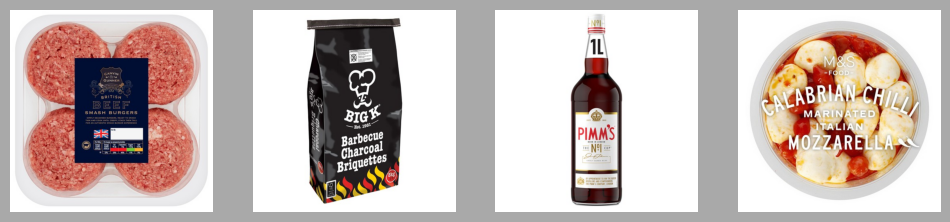


Processed images


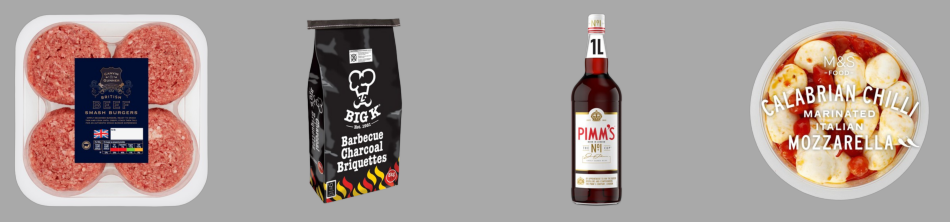

In [ ]:
for index, row in df.iterrows():
    df.loc[index, 'seg_image_path'] = remove_background(row.local_image_path)
# display(df)

print("\nOriginal images")
display_row([PIL_Image.open(path) for path in df.local_image_path.to_list()], bg="darkgray")
print("\nProcessed images")
display_row([PIL_Image.open(path) for path in df.seg_image_path.to_list()], bg="darkgray")

## Define offers

In [ ]:
offers = [
    "Save 10%",
    "Save 10%",
    "Save 20%",
    "Save 10%",
]

## Define prompt

In [ ]:
# banner_brief = "Hot weather and barbeques"
banner_brief = "British barbeques in the rain still work"

df_input = df[['title', 'price', 'seg_image_path']].copy()
df_input.columns = ['title', 'now_price', 'image_path']
df_input['offer'] = offers
# display(Markdown(f"**Brief given**: {banner_brief} \n\n**Products**:"))
# display(df_input)

In [ ]:
prompt = f"""
You are a marketing copywriter for an e-commerce team.
Your task is to create a compelling headline and a short, snappy sub-headline for a promotional banner.

**Creative Brief:**
{banner_brief}

**Products to Feature:**
{df.title.to_markdown()}

**Instructions:**
- The headline should be powerful and grab attention.
- The sub-headline should be concise and complementary.
- Do not include "Shop now" or any call to action.
- Provide ONLY the headline and sub-headline.

**Output Format:**
{{
  "headline": "The main selling point",
  "sub_headline": "A catchy supporting phrase"
}}

**Sample Outputs:**

{{
"headline": "New & Trending",
"sub_headline": "Check out the latest and greatest this month."
}}

{{
"headline": "Everyday Savers",
"sub_headline": "Low prices on your most-loved groceries."
}}

{{
"headline": "Thanks, Mum",
"sub_headline": "Mother's Day 10th March"
}}
"""

In [ ]:
display(Markdown(prompt))


You are a marketing copywriter for an e-commerce team.
Your task is to create a compelling headline and a short, snappy sub-headline for a promotional banner.

**Creative Brief:**
British barbeques in the rain still work

**Products to Feature:**
|    | title                                                  |
|---:|:-------------------------------------------------------|
|  0 | Canvin & Gunner Smash Burgers 400g                     |
|  1 | Big K Barbecue Charcoal Briquettes FSC 3kg             |
|  2 | Pimm's No.1 Cup 1L                                     |
|  3 | M&S Calabrian Chilli Marinated Italian Mozzarella 160g |

**Instructions:**
- The headline should be powerful and grab attention.
- The sub-headline should be concise and complementary.
- Do not include "Shop now" or any call to action.
- Provide ONLY the headline and sub-headline.

**Output Format:**
{
  "headline": "The main selling point",
  "sub_headline": "A catchy supporting phrase"
}

**Sample Outputs:**

{
"headline": "New & Trending",
"sub_headline": "Check out the latest and greatest this month."
}

{
"headline": "Everyday Savers",
"sub_headline": "Low prices on your most-loved groceries."
}

{
"headline": "Thanks, Mum",
"sub_headline": "Mother's Day 10th March"
}


## Get copy using Gemini 2.5 Flash

In [ ]:
copy = json.loads(get_copy(prompt))
print(copy)

{'headline': 'Rain or Shine, the Grill is Fine.', 'sub_headline': "British BBQs: We've got you covered, even in a downpour."}


## Create banner

Banner saved as outputs/bbq_v2.png


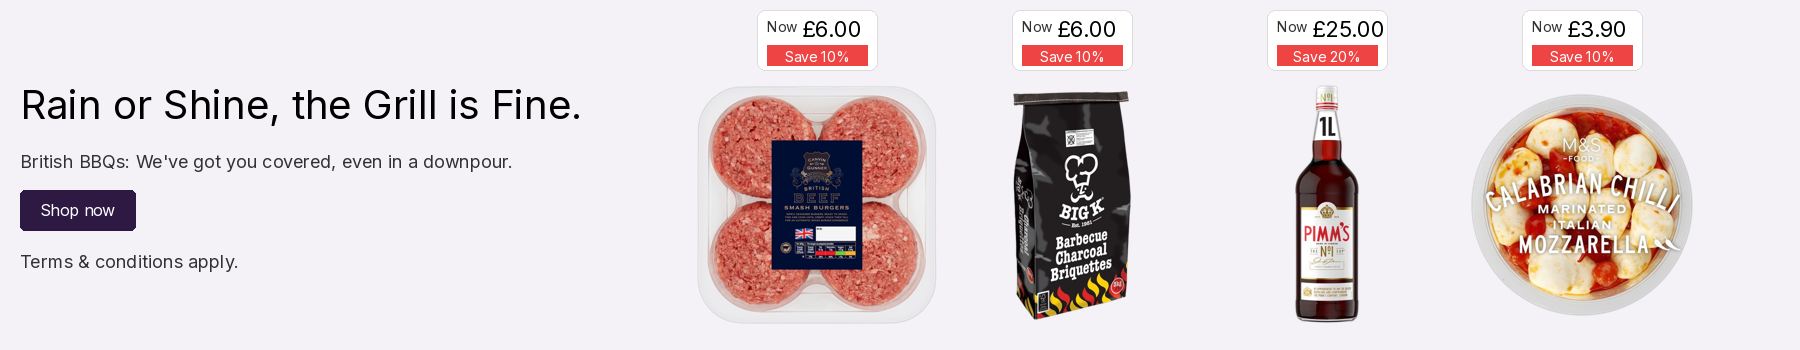

In [ ]:
!mkdir outputs
output_filename = "outputs/bbq_v2.png"

create_banner(
    headline=copy['headline'],
    subheadline=copy['sub_headline'],
    cta_text="Shop now",
    terms_text="Terms & conditions apply.",
    products=df_input[['image_path', 'now_price', 'offer']].to_dict(orient='records'),
    output_filename=output_filename,
)
PIL_Image.open(output_filename)

## Older things